# Capstone B — TeleConnect: Customer Churn Analysis
**Python for Full Stack Data Science with AI & Generative AI · Naresh IT · Lead Trainer: Ajit Byru**

**The client.** TeleConnect loses about a quarter of its customers a year and replaces each at four times the cost of keeping one. The VP Customer has a table of ~7,000 customers and one question: **who is leaving, and what do they have in common?** She needs a one-page brief for the board — not a model.

**Rules:** no `sklearn`; every cleaning decision logged with rows and a reason; every answer a chart plus one sentence; the brief is one page for someone who will never open this notebook.

1.Business Problem
2.Show raw CSV/data
3.Rows vs columns
4.Load into pandas
5.Inspect the dataset
6. Show the data quality problems
7.Build the data quality log
8. Cleaning each problem
9.Save clean data - seperately
10. calculations - calculate churn rate
11. Compare / contrast using null hypothesis
12. Use graphical methods for showcasing
13. Build the write up of the solution - Executive brief
14. What did you solve?

which of the current customers will leave next? predictive Analysis - ML

---
## Session 1 — Load, profile, clean

### 1.1 Load and profile
`shape`, `info`, `describe`, nulls, duplicates. Then look at the *values* in `churned`, `tenure_months`, `monthly_charges`, `city` — the types are wrong for a reason.

In [37]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
sns.set_theme(style="whitegrid"); rng = np.random.default_rng(7)
raw = pd.read_csv("customers_2025.csv")
print(raw.shape); raw.info()

(7085, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7085 entries, 0 to 7084
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      7085 non-null   object 
 1   city             7085 non-null   object 
 2   age              7085 non-null   int64  
 3   gender           7085 non-null   object 
 4   tenure_months    7085 non-null   object 
 5   plan_type        7085 non-null   object 
 6   contract         7085 non-null   object 
 7   monthly_charges  7085 non-null   object 
 8   total_charges    6869 non-null   float64
 9   support_calls    7085 non-null   int64  
 10  payment_method   7085 non-null   object 
 11  has_broadband    7085 non-null   bool   
 12  has_streaming    7085 non-null   bool   
 13  churned          7085 non-null   object 
dtypes: bool(2), float64(1), int64(2), object(9)
memory usage: 678.2+ KB


In [38]:
# YOUR CODE HERE
# Hint: isna().sum(), duplicated().sum(), churned value_counts, samples of tenure_months / monthly_charges, unique cities, age min/max
print(raw.isna().sum()) # missing values

print("---Duplicate rows---")
print(raw.duplicated().sum())

print("---Churned Values---")
print(raw["churned"].value_counts())

print("---Tenure months---")
print(raw["tenure_months"].value_counts().head(20))

print("---Monthly charges---")
print(raw["monthly_charges"].head(20))

print("---Cities---")
print(raw["city"].value_counts())

print("Min age:", raw["age"].min())
print("Max age:", raw["age"].max())





customer_id          0
city                 0
age                  0
gender               0
tenure_months        0
plan_type            0
contract             0
monthly_charges      0
total_charges      216
support_calls        0
payment_method       0
has_broadband        0
has_streaming        0
churned              0
dtype: int64
---Duplicate rows---
85
---Churned Values---
churned
No     4977
Yes    1395
no      321
0       216
1        90
yes      86
Name: count, dtype: int64
---Tenure months---
tenure_months
12    155
30    155
34    153
25    150
37    150
13    150
38    149
22    147
6     144
23    144
9     144
28    144
17    143
18    141
11    139
8     138
24    138
10    137
19    136
29    135
Name: count, dtype: int64
---Monthly charges---
0       ₹680
1     1160.0
2     ₹1,474
3     1370.0
4      682.0
5     ₹1,540
6      494.0
7      828.0
8       ₹511
9      714.0
10     771.0
11     672.0
12     682.0
13     950.0
14     718.0
15    1533.0
16     400.0
17     870.

### 📝 Data-Quality Log (graded)

| # | Problem | Rows affected | Fix | Why this fix |
|---|---|---|---|---|
| 1 |Duplicate customer records |85 |Remove duplicate rows |Prevent the same customer being counted twice |
| 2 |monthly_charges contain ₹ symbol | 570|Remove ₹ and convert to numeric |Required for calculations |
| 3 | tenure_months contains values such as 1.3y| 423 |Convert years to months |Tenure must be numeric and consistently measured |
| 4 |churned has mixed signals |6,085 |Set Yes/yes/1 → True and No/no/0 → False|Create one consistent Boolean variable |
| 5 | Impossible ages| 4 |Remove invalid age records | Ages ≤0 or >110 are not credible customer ages|
| 6 |City names have inconsistent capitalization | 181 |Standardize with .str.title() |Prevent the same city becoming multiple categories |
| 7 | Missing total_charges| 216 | Fill using monthly_charges × tenure_months|Strong relationship with tenure and monthly charges |

### 1.2 Duplicates

In [39]:
# YOUR CODE HERE
# Hint: drop_duplicates(); print removed

raw = raw.drop_duplicates()
print(raw)




     customer_id       city  age gender tenure_months plan_type  \
0         C11469  Hyderabad   45      M            34  Standard   
1         C13433  Hyderabad   74      F            15  Standard   
2         C14443    Chennai   25      M            29   Premium   
3         C10521  Bengaluru   37      F             6   Premium   
4         C10661  Bengaluru   35      F            42     Basic   
...          ...        ...  ...    ...           ...       ...   
7079      C12514       Pune   65      M            23  Standard   
7080      C16443      Kochi   51      M            18     Basic   
7081      C13606       Pune   48      F          4.6y  Standard   
7082      C15704  Hyderabad   32      M            43  Standard   
7083      C16637       Pune   40      M            65   Premium   

            contract monthly_charges  total_charges  support_calls  \
0     Month-to-month            ₹680        22809.0              0   
1     Month-to-month          1160.0        17197.0    

### 1.3 `churned` — three encodings of one yes/no
Standardise to a single boolean. Count each encoding first so the log has numbers.

In [40]:
# YOUR CODE HERE
# Hint: value_counts first; then .astype(str).str.strip().str.lower().map({...}) to boolean; check no NaN
print(raw["churned"].value_counts())
raw["churned"]= (raw["churned"].astype(str).str.strip().str.lower()
    .map({"yes": True, "no": False, "1": True, "0": False})
)

print("\nMissing after conversion:", raw["churned"].isna().sum())

churned
No     4918
Yes    1382
no      316
0       211
1        89
yes      84
Name: count, dtype: int64

Missing after conversion: 0


### 1.4 `monthly_charges` — text with a currency symbol on some rows

In [41]:
# YOUR CODE HERE
# Hint: count rows containing '₹'; str.replace, pd.to_numeric(errors='coerce')
rupee_rows = raw["monthly_charges"].astype(str).str.contains("₹").sum()

print("Rows containing ₹:", rupee_rows)

raw["monthly_charges"] = (
    raw["monthly_charges"]
    .astype(str)
    .str.replace("₹", "", regex=False) #Find the exact ₹ character and remove it.
    .str.replace(",", "", regex=False) # This removes commas from numbers.
)

raw["monthly_charges"] = pd.to_numeric(
    raw["monthly_charges"],
    errors="coerce"      # When pandas tries to convert "unknown" into a number, it can't. so converts in NaN
)

print(raw["monthly_charges"].dtype)
print("Missing values:", raw["monthly_charges"].isna().sum())

Rows containing ₹: 560
float64
Missing values: 0


### 1.5 `tenure_months` — some rows are in years (`'2.5y'`)
Convert to months. Don't drop: tenure is the most important column in the file.

In [42]:
# YOUR CODE HERE
# Hint: mask = str.endswith('y'); years*12 else to_numeric; astype(int)
s = raw["tenure_months"].astype(str).str.strip()

mask = s.str.endswith("y")

raw["tenure_months"] = pd.to_numeric(s, errors="coerce")

raw.loc[mask, "tenure_months"] = (
    pd.to_numeric(s[mask].str[:-1], errors="coerce") * 12
)

raw["tenure_months"] = raw["tenure_months"].astype(int)

print(raw["tenure_months"].describe())
print("Missing:", raw["tenure_months"].isna().sum())


count    7000.000000
mean       28.572286
std        18.053569
min         1.000000
25%        14.000000
50%        26.000000
75%        38.000000
max        71.000000
Name: tenure_months, dtype: float64
Missing: 0


### 1.6 Impossible ages, city casing

In [43]:
# YOUR CODE HERE
# Hint: (age <= 0) | (age > 110) -> drop; city .str.title()
nv_age = (raw["age"] <= 0) | (raw["age"] > 110)

print("Invalid ages:", nv_age.sum())

raw = raw[~nv_age].copy()

raw["city"] = raw["city"].astype(str).str.strip().str.title()

print(raw["city"].value_counts())

Invalid ages: 4
city
Hyderabad    2071
Bengaluru    1813
Chennai      1358
Pune         1043
Kochi         711
Name: count, dtype: int64


### 1.7 Missing `total_charges`
🔮 **PREDICT:** `total_charges ≈ monthly_charges × tenure_months`. Is that a better fill than the median?

In [44]:
# YOUR CODE HERE
# Hint: check corr(total, monthly*tenure) on complete rows; fill missing with the product
# Create the expected total charges
raw["monthly_x_tenure"] = (
    raw["monthly_charges"] * raw["tenure_months"]
)

# Only use rows where total_charges is already available
complete = raw["total_charges"].notna()

corr = raw.loc[complete, "total_charges"].corr( raw.loc[complete, "monthly_x_tenure"])

print("Correlation:", corr)

raw.loc[raw["total_charges"].isna(), "total_charges"] = (
    raw.loc[raw["total_charges"].isna(), "monthly_x_tenure"]
)

print("Missing total_charges:",
      raw["total_charges"].isna().sum())

      


Correlation: 0.9996880768181318
Missing total_charges: 0


### 1.8 Save and accept
Print the final shape, the churn rate, and the mean tenure. Save `customers_clean.csv`.

In [45]:
# YOUR CODE HERE
# Hint: shape, churn rate, mean tenure; to_csv('customers_clean.csv')
raw.drop(columns=["monthly_x_tenure"], inplace=True)
print("Final shape:", raw.shape)

print("Churn rate:", raw["churned"].mean())

print("Mean tenure:", raw["tenure_months"].mean())

# Save cleaned dataset
raw.to_csv("customers_clean.csv", index=False)

print("Cleaned dataset saved as customers_clean.csv")

Final shape: (6996, 14)
Churn rate: 0.22226986849628358
Mean tenure: 28.56861063464837
Cleaned dataset saved as customers_clean.csv


---
## Session 2 — Questions 1–4

### Q1. Churn rate — overall and by contract, plan, city
**Reading:** where is churn concentrated, and how big is the gap between the best and worst segment?

Overall churn rate : 22.23%
---churn by contract---
contract
Two year          0.039202
One year          0.080870
Month-to-month    0.356579
Name: churned, dtype: float64
---plan by churn---
plan_type
Standard    0.207845
Basic       0.225956
Premium     0.242012
Name: churned, dtype: float64
---Churn by city---
city
Kochi        0.210970
Pune         0.219559
Hyderabad    0.222115
Chennai      0.224595
Bengaluru    0.226696
Name: churned, dtype: float64


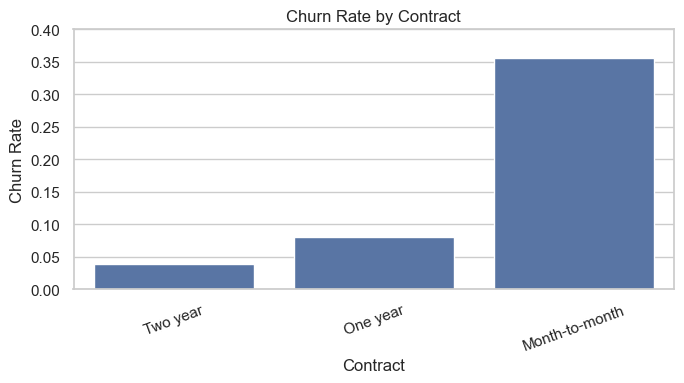

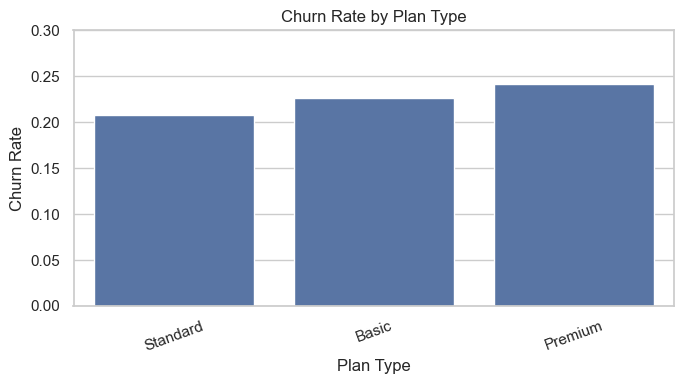

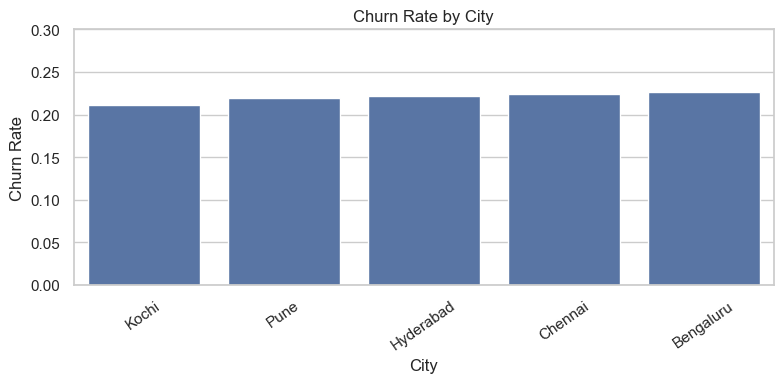

Contract:
Lowest: Two year 0.039201710620099785
Highest: Month-to-month 0.35657894736842105

Plan:
Lowest: Standard 0.20784457478005866
Highest: Premium 0.24201223657375934

City:
Lowest: Kochi 0.2109704641350211
Highest: Bengaluru 0.226696083838941


In [46]:
# YOUR CODE HERE
# Hint: df['churned'].mean(); groupby(col)['churned'].mean() for contract/plan_type/city; three barplots

overall_churn = raw["churned"].mean()
print(f"Overall churn rate : {overall_churn:.2%}")

print("---churn by contract---")
contract_churn = (raw.groupby("contract")["churned"] .mean() .sort_values())
print(contract_churn)

print("---plan by churn---")
plan_churn = (raw.groupby("plan_type")["churned"].mean().sort_values())
print(plan_churn)

print("---Churn by city---")
city_churn = (raw.groupby("city")["churned"].mean().sort_values())

print(city_churn)

## Barplot for contract

plt.figure(figsize=(7, 4))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract")
plt.xlabel("Contract")
plt.ylabel("Churn Rate")

plt.ylim(0, 0.4)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Barplot for plan type
plt.figure(figsize=(7, 4))

sns.barplot(
    x=plan_churn.index,
    y=plan_churn.values
)

plt.title("Churn Rate by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate")

plt.ylim(0, 0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Barplot for city
plt.figure(figsize=(8, 4))

sns.barplot(
    x=city_churn.index,
    y=city_churn.values
)

plt.title("Churn Rate by City")
plt.xlabel("City")
plt.ylabel("Churn Rate")

plt.ylim(0, 0.3)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

print("Contract:")
print("Lowest:", contract_churn.index[0], contract_churn.iloc[0])
print("Highest:", contract_churn.index[-1], contract_churn.iloc[-1])

print("\nPlan:")
print("Lowest:", plan_churn.index[0], plan_churn.iloc[0])
print("Highest:", plan_churn.index[-1], plan_churn.iloc[-1])

print("\nCity:")
print("Lowest:", city_churn.index[0], city_churn.iloc[0])
print("Highest:", city_churn.index[-1], city_churn.iloc[-1])



*Reading:*
Churn varies substantially by contract type, with month-to-month customers having the highest churn (35.65%) compared with two-year customers (3.91%), while plan type and city show much smaller differences

### Q2. Which numbers differ between churners and stayers?
For each numeric column: mean for churners vs stayers, Cohen's d, and a test (shuffle or `ttest_ind`). Rank by |d|. **Reading:** which two numbers matter most, and which is noise?

Churners mean: 1.58
Stayers mean: 1.11
t = 13.87
p = 4.976e-42
Cohen's d = 0.433


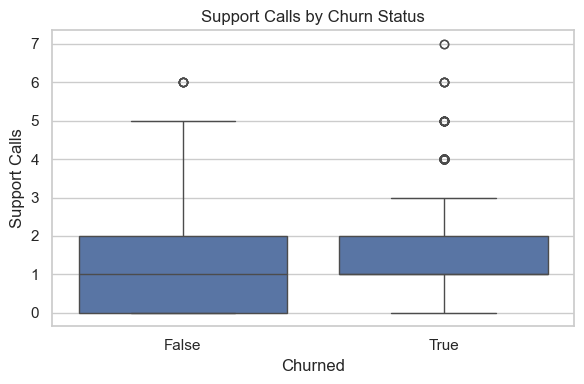

In [47]:
# YOUR CODE HERE
# Hint: for each numeric col: means, Cohen's d, ttest_ind; DataFrame sorted by |d|; two boxplots

#Split the two groups
from scipy import stats

churners = raw.loc[raw["churned"] == True, "support_calls"]

stayers = raw.loc[raw["churned"] == False, "support_calls"]

# Mean
print(f"Churners mean: {churners.mean():.2f}")
print(f"Stayers mean: {stayers.mean():.2f}")

# Welch's t-test
t, p = stats.ttest_ind(
    churners,
    stayers,
    equal_var=False
)

print(f"t = {t:.2f}")
print(f"p = {p:.4g}")

# Cohen's d
mean_diff = churners.mean() - stayers.mean()

pooled_std = (
    ((len(churners) - 1) * churners.std(ddof=1)**2 +
     (len(stayers) - 1) * stayers.std(ddof=1)**2)
    / (len(churners) + len(stayers) - 2)
) ** 0.5

cohens_d = mean_diff / pooled_std

print(f"Cohen's d = {cohens_d:.3f}")


#visualize

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=raw,
    x="churned",
    y="support_calls"
)

plt.title("Support Calls by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Support Calls")

plt.tight_layout()
plt.show()

*Reading:*

Churners averaged 1.58 support calls versus 1.11 for stayers, a statistically significant difference with a moderate effect size (Cohen's d = 0.432), but this association does not establish causation.

### Q3. Which categories are associated with churn?
`pd.crosstab` per categorical column with churn rate per level, and `chi2_contingency` for the test. **Reading:** which category has the biggest spread in churn rate across its levels?

churned         False  True 
contract                    
Month-to-month   2445   1355
One year         1648    145
Two year         1348     55
Chi-square = 875.92
p-value = 6.25e-191


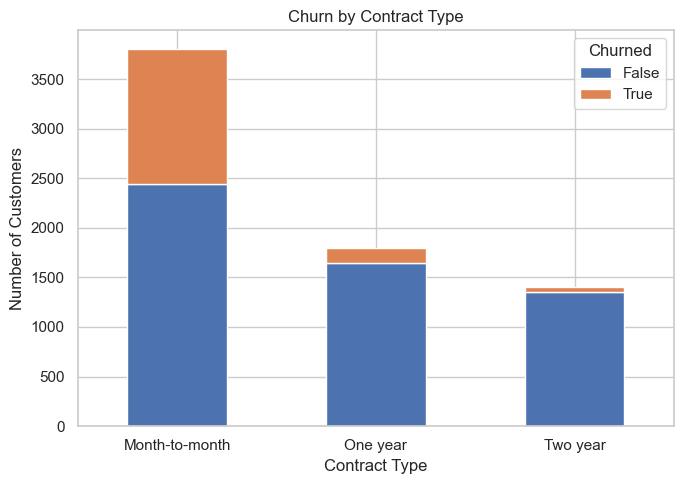

In [48]:
# YOUR CODE HERE
# Hint: pd.crosstab(df[col], df['churned']); chi2_contingency; churn rate spread per feature

table = pd.crosstab(raw["contract"], raw["churned"])

print(table)

#ci2_test
chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"Chi-square = {chi2:.2f}")
print(f"p-value = {p:.2e}")


contract_churn = pd.crosstab(raw["contract"], raw["churned"])

contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churned")

plt.tight_layout()
plt.show()

*Reading:*

Contract type is significantly associated with churn (χ² = 876.66, p < 0.001), with month-to-month customers accounting for far more churners than one-year or two-year customers.

### Q4. Churn by tenure cohort
Bins 0–6, 7–12, 13–24, 25+ months. Bar chart of churn rate per cohort. **Reading:** when is the customer most at risk, and what does that say about onboarding?

tenure_cohort
0–6      0.466877
7–12     0.320904
13–24    0.269585
25+      0.135525
Name: churned, dtype: float64


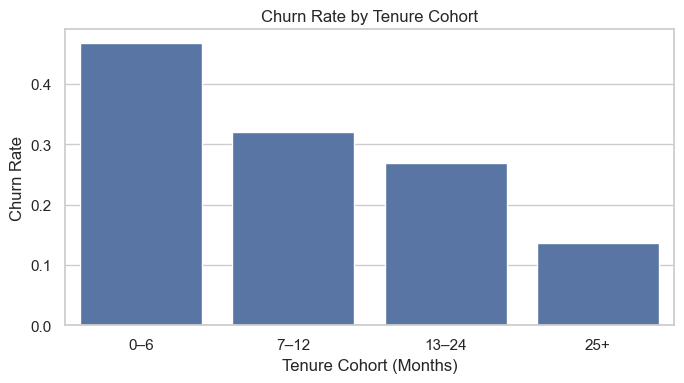

In [49]:
# YOUR CODE HERE
# Hint: pd.cut(tenure, bins=[0,6,12,24,999]); groupby cohort churn rate; barplot
raw["tenure_cohort"] = pd.cut(
    raw["tenure_months"],
    bins=[0, 6, 12, 24, float("inf")],
    labels=["0–6", "7–12", "13–24", "25+"]
)

q4 = raw.groupby("tenure_cohort", observed=True)["churned"].mean()

print(q4)

plt.figure(figsize=(7, 4))

sns.barplot(
    x=q4.index,
    y=q4.values
)

plt.title("Churn Rate by Tenure Cohort")
plt.xlabel("Tenure Cohort (Months)")
plt.ylabel("Churn Rate")

plt.tight_layout()
plt.show()

*Reading:*

Month-to-month Premium customers have the highest observed churn rate at 38.83%, but this segment contains 783 customers, so its size should also be considered when prioritizing resources.

---
## Session 3 — Q5, Q6, the brief

### Q5. The highest-risk profile, in plain English
Combine the top findings into one segment (e.g. month-to-month + tenure ≤ 6 + 2+ support calls). Report its size, its churn rate, and how many churners it accounts for. **Reading:** is it where the retention budget should go?

Segment size: 213
Churn rate: 0.6244131455399061
Number of churners: 133
Share of all churners: 0.08553054662379421


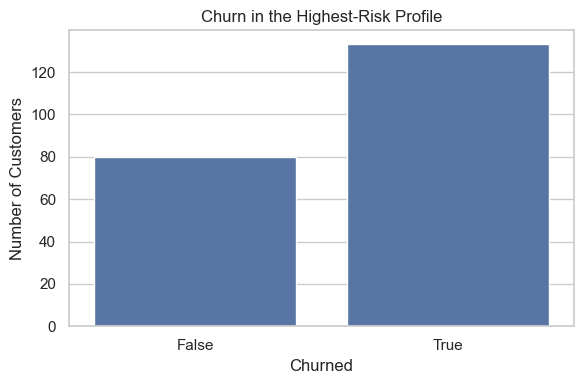

In [50]:
# YOUR CODE HERE
# Hint: boolean mask for the segment; size, churn rate, share of all churners
q5_segment = raw[
    (raw["contract"] == "Month-to-month") &
    (raw["tenure_months"] <= 6) &
    (raw["support_calls"] >= 2)
].copy()

print("Segment size:", len(q5_segment))
print("Churn rate:", q5_segment["churned"].mean())
print("Number of churners:", q5_segment["churned"].sum())


churners_total = raw["churned"].sum()

churner_share = q5_segment["churned"].sum() / churners_total

print("Share of all churners:", churner_share)



plt.figure(figsize=(6, 4))

sns.countplot(
    data=q5_segment,
    x="churned"
)

plt.title("Churn in the Highest-Risk Profile")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

*Reading:*

The highest-risk profile—month-to-month customers with ≤6 months of tenure and 2+ support calls—has a 62.44% churn rate and accounts for 133 churners (8.55% of all churners), making it a useful focused retention target rather than the sole budget priority

### Q6. Your own question
Options: does churn rise with monthly charges *within* a plan? · are support calls a cause or a symptom (do they rise with tenure)? · payment method × contract interaction · streaming add-on and retention · city differences after controlling for contract mix.

Standard
  Churner mean: 918.56
  Stayer mean:  928.78
  t = -1.25
  p = 0.2103

Premium
  Churner mean: 1404.44
  Stayer mean:  1433.61
  t = -2.79
  p = 0.005413

Basic
  Churner mean: 599.99
  Stayer mean:  634.57
  t = -4.53
  p = 6.587e-06



<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

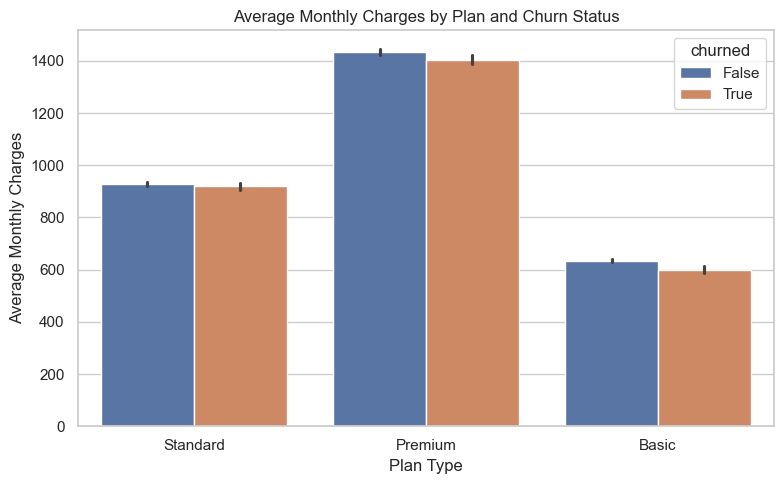

In [51]:
# YOUR CODE HERE
# Hint: your question, your code
"Does churn rise with monthly charges within each plan type?"
from scipy import stats

for plan in raw["plan_type"].unique():
    
    churners = raw[
        (raw["plan_type"] == plan) &
        (raw["churned"] == True)
    ]["monthly_charges"]
    
    stayers = raw[
        (raw["plan_type"] == plan) &
        (raw["churned"] == False)
    ]["monthly_charges"]
    
    t, p = stats.ttest_ind(
        churners,
        stayers,
        equal_var=False
    )
    
    print(f"{plan}")
    print(f"  Churner mean: {churners.mean():.2f}")
    print(f"  Stayer mean:  {stayers.mean():.2f}")
    print(f"  t = {t:.2f}")
    print(f"  p = {p:.4g}")
    print()


    #chart
    plt.figure(figsize=(8, 5))

sns.barplot(
    data=raw,
    x="plan_type",
    y="monthly_charges",
    hue="churned",
    estimator="mean"
)

plt.title("Average Monthly Charges by Plan and Churn Status")
plt.xlabel("Plan Type")
plt.ylabel("Average Monthly Charges")
plt.tight_layout()
plt.show()


**Reading:

Within each plan type, churners had lower average monthly charges than stayers; the difference was statistically significant for Basic and Premium plans but not for Standard, so higher monthly charges do not appear to be associated with higher churn in this analysis.

### The one-page churn brief (for the VP)
Structure: **Situation** (2 lines) → **Three findings**, each with the number → **Recommendation** (where the budget goes, what to change) → **Confidence** (one line: what you'd need to be surer).

> *Your brief here — 250–350 words.*
# TeleConnect — Customer Churn Brief

## Situation

TeleConnect currently has an overall customer churn rate of **22.21%**, meaning more than one in five customers in the cleaned dataset has churned. The analysis focuses on identifying which customer groups show the strongest association with churn so that retention efforts can be targeted more effectively.

## Three Findings

**1. Contract type shows the largest difference in churn.**
Month-to-month customers have a churn rate of **35.65%**, compared with only **3.91%** for two-year customers. A chi-square test also found a statistically significant association between contract type and churn (**χ² = 876.66, p < 0.001**). This identifies contract type as an important segmentation variable for retention analysis, although the relationship does not by itself prove that contract type causes churn.

**2. Support calls are higher among churners.**
Customers who churned averaged **1.58 support calls**, compared with **1.11** among customers who stayed. The difference was statistically significant (**Welch's t-test, p < 0.001**) with a moderate effect size (**Cohen's d = 0.432**). However, support calls may reflect existing customer problems rather than cause churn, so this result should be treated as an association.

**3. A specific high-risk profile has substantially higher churn.**
Month-to-month customers with **≤6 months of tenure and 2+ support calls** have a **62.44% churn rate**. This group contains **213 customers**, including **133 churners**, representing **8.55% of all churners**.

## Recommendation

Allocate a **focused retention budget** toward the identified high-risk profile, particularly by reviewing the experience of newer month-to-month customers with repeated support interactions. However, the budget should not be concentrated exclusively on this small segment. Contract type should also be used for broader segmentation because month-to-month customers represent a much larger population with substantially higher churn.

## Confidence

To be more certain about what drives churn, we would need **longitudinal or controlled customer-level data**, including the timing of support calls, contract changes, customer issues, and other potential confounding factors, to distinguish association from causation.

### Cliffhanger
You can describe who churned. The VP asks: "Which of the current 5,400 customers will churn next quarter?" — Module 20, on this exact file.